# Iris Flower Classification

**Objective:** Train a machine learning classification model to identify the species of an
iris flower — *Setosa*, *Versicolor*, or *Virginica* — from four physical measurements:
sepal length, sepal width, petal length, and petal width.

**Workflow:**
1. Load the data
2. Exploratory Data Analysis (EDA)
3. Visualisations
4. Feature selection discussion
5. Train/test split
6. Train multiple classifiers
7. Evaluate each model
8. Select and justify the best-performing model


In [1]:
# ---- Core libraries ----
import numpy as np
import pandas as pd

# ---- Visualisation ----
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Data & preprocessing ----
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import f_classif

# ---- Models ----
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# ---- Evaluation ----
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

# Plot styling
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42


## 1. Load the Dataset

The Iris dataset ships directly with scikit-learn, so no download or file upload is needed.
We load it and assemble it into a tidy `pandas` DataFrame with a human-readable `species`
column (rather than the raw integer target) for easier plotting and reading.


In [2]:
iris = load_iris()

# Build a tidy DataFrame: 4 feature columns + numeric target + readable species name
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["target"] = iris.target
df["species"] = df["target"].map(dict(enumerate(iris.target_names)))

df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## 2. Exploratory Data Analysis (EDA)

Before modelling, we check the shape of the data, the data types, whether there are any
missing values, and the descriptive statistics of each feature.


In [3]:
print(f"Shape of dataset: {df.shape[0]} rows x {df.shape[1]} columns")


Shape of dataset: 150 rows x 6 columns


In [4]:
# Data types of each column
df.dtypes


sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
target                 int64
species                  str
dtype: object

In [5]:
# Null / missing value check
print("Missing values per column:")
df.isnull().sum()


Missing values per column:


sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64

In [6]:
# Descriptive statistics for the numeric feature columns
df.describe()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [7]:
# Class balance — is each species equally represented?
df["species"].value_counts()


species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

**Observations:**
- The dataset has **150 rows and 4 numeric features**, plus the target/species labels — no missing values at all.
- All three species are **perfectly balanced** at 50 samples each, so accuracy is a fair evaluation metric (no class-imbalance correction needed).
- Feature scales differ somewhat (e.g. petal length ranges much wider than sepal width), which matters for distance-based models like KNN.


## 3. Visualisations

### 3.1 Pairplot (scatter matrix)
A pairplot shows every feature plotted against every other feature, coloured by species.
This is the fastest way to see which features separate the classes well.


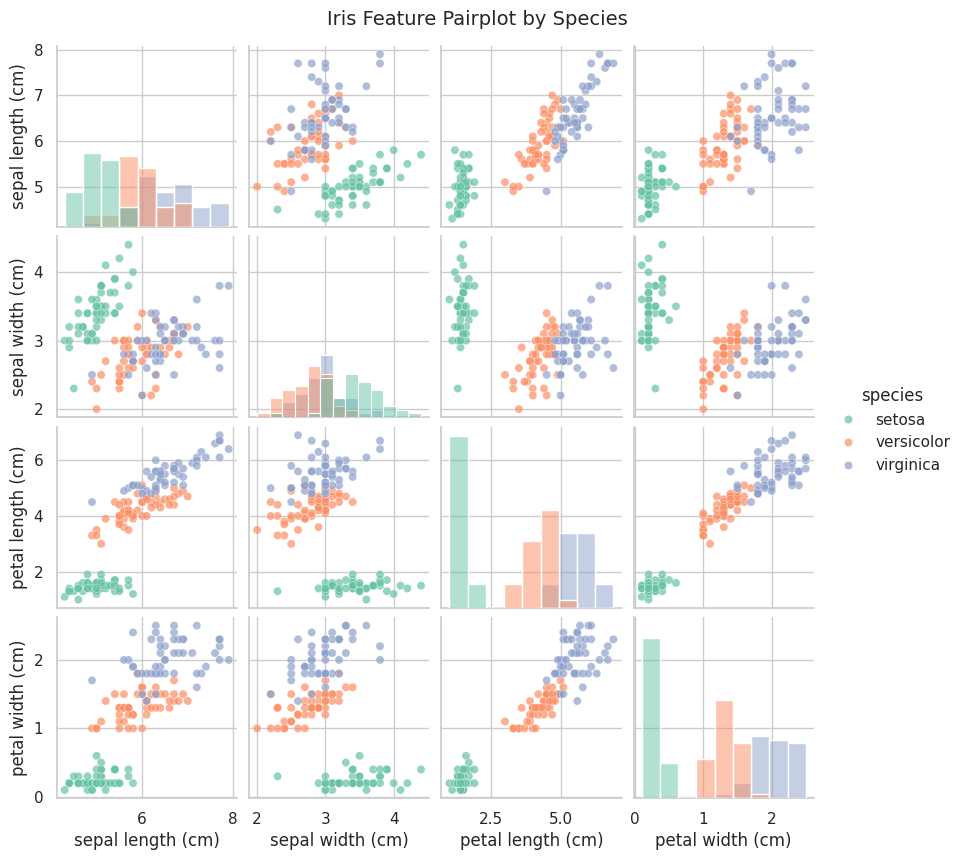

In [8]:
pairplot = sns.pairplot(
    df,
    vars=iris.feature_names,
    hue="species",
    diag_kind="hist",
    plot_kws={"alpha": 0.7, "s": 35, "edgecolor": "white", "linewidth": 0.3},
    height=2.1,
)
pairplot.fig.suptitle("Iris Feature Pairplot by Species", y=1.02, fontsize=14)
plt.show()


### 3.2 Box plots per feature

Box plots let us compare the distribution (median, spread, outliers) of each feature across
the three species side by side.


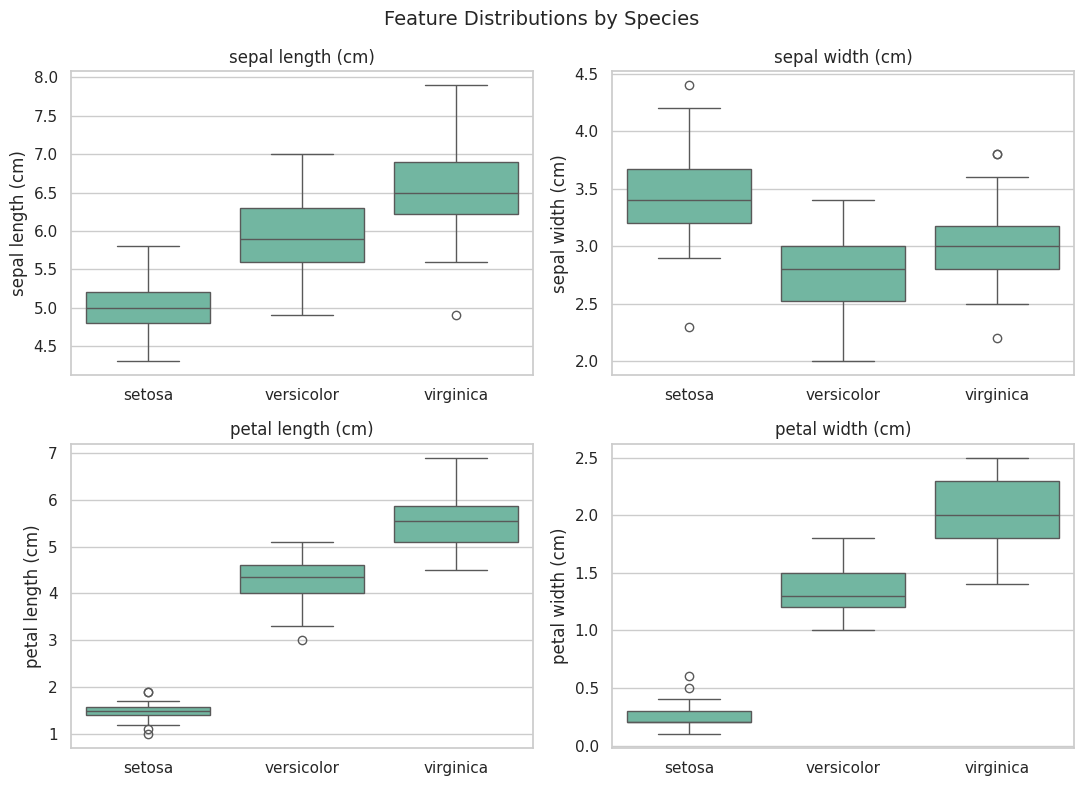

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.ravel()

for ax, feature in zip(axes, iris.feature_names):
    sns.boxplot(data=df, x="species", y=feature, ax=ax)
    ax.set_title(feature)
    ax.set_xlabel("")

fig.suptitle("Feature Distributions by Species", fontsize=14)
fig.tight_layout()
plt.show()


### 3.3 Correlation heatmap

A quick look at how strongly the four features correlate with one another.


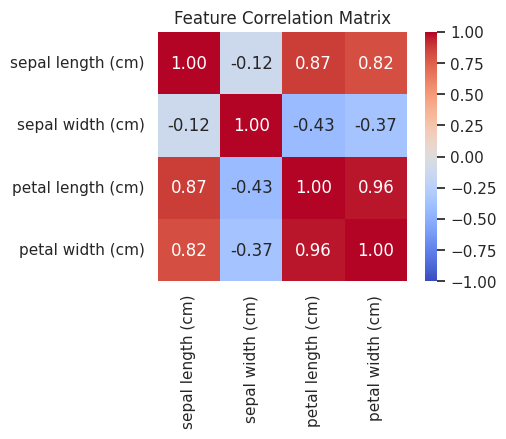

In [10]:
plt.figure(figsize=(5.5, 4.5))
corr = df[iris.feature_names].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()


## 4. Feature Selection Discussion

From the pairplot and box plots above:

- **Petal length** and **petal width** show almost no overlap between species — *Setosa* is
  cleanly separated from the other two by a wide margin, and *Versicolor* / *Virginica*
  overlap only slightly. These two features are visually the most discriminative.
- **Sepal length** and especially **sepal width** show much more overlap between
  *Versicolor* and *Virginica*, making them individually weaker predictors.
- The correlation heatmap confirms petal length and petal width are strongly correlated with
  each other (~0.96), meaning they carry overlapping but individually powerful signal.

We can back this qualitative reading up with a quick **ANOVA F-test** (`f_classif`), which
scores how well each feature separates the three classes — a higher F-score means the
feature's class means are more different relative to within-class variance.


In [11]:
f_scores, p_values = f_classif(df[iris.feature_names], df["target"])

feature_scores = pd.DataFrame({
    "feature": iris.feature_names,
    "F_score": f_scores,
    "p_value": p_values,
}).sort_values("F_score", ascending=False)

feature_scores


,feature,F_score,p_value
2,petal length (cm),1180.161182,2.856777e-91
3,petal width (cm),960.007147,4.169446e-85
0,sepal length (cm),119.264502,1.669669e-31
1,sepal width (cm),49.160040,4.492017e-17


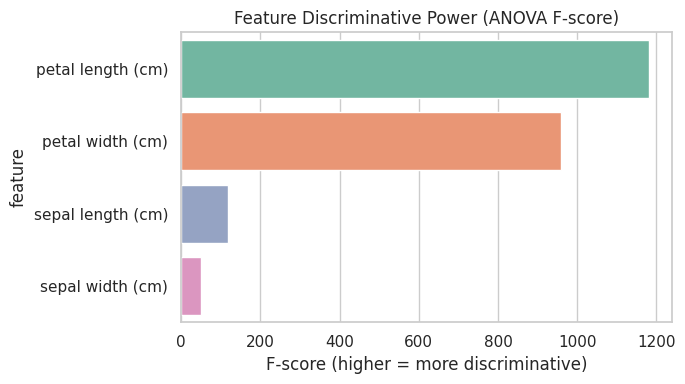

In [12]:
plt.figure(figsize=(7, 4))
sns.barplot(data=feature_scores, x="F_score", y="feature", hue="feature", palette="Set2", legend=False)
plt.title("Feature Discriminative Power (ANOVA F-score)")
plt.xlabel("F-score (higher = more discriminative)")
plt.tight_layout()
plt.show()


**Conclusion:** `petal length (cm)` and `petal width (cm)` have by far the highest F-scores
and the clearest visual separation — they are the two most discriminative features for
telling the species apart. `sepal length` and `sepal width` still carry useful information
(and are cheap to keep, since the dataset is tiny), so for this project we'll **train the
models on all four features** rather than dropping any — with only 4 features total there is
no overfitting or dimensionality concern, and the weaker features can still help resolve
borderline *Versicolor*/*Virginica* cases. In a higher-dimensional dataset, we would drop
low-F-score features to reduce noise; here it isn't necessary.


## 5. Train/Test Split

We hold out 20% of the data for testing and train on the remaining 80%, using stratified
sampling so each split preserves the original 50/50/50 class balance.


In [13]:
X = df[iris.feature_names]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print("\nClass balance in training set:")
print(y_train.value_counts(normalize=True).round(3))
print("\nClass balance in test set:")
print(y_test.value_counts(normalize=True).round(3))


Training set: 120 samples
Test set:     30 samples

Class balance in training set:
target
0    0.333
2    0.333
1    0.333
Name: proportion, dtype: float64

Class balance in test set:
target
0    0.333
2    0.333
1    0.333
Name: proportion, dtype: float64


## 6. Train Multiple Classifiers

We train **four** different classifiers so we can compare approaches:

1. **Logistic Regression** — a simple, interpretable linear baseline
2. **K-Nearest Neighbours (KNN)** — a distance-based, non-parametric method
3. **Decision Tree** — a single interpretable tree with explicit rules
4. **Random Forest** — an ensemble of many decision trees

Logistic Regression and KNN are distance/scale-sensitive, so we wrap them in a `Pipeline`
with `StandardScaler`. Tree-based models (Decision Tree, Random Forest) are scale-invariant,
so they're trained directly on the raw features.


In [14]:
models = {
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    "K-Nearest Neighbours": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
    "Decision Tree": DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
}

# Fit every model on the training data
for name, model in models.items():
    model.fit(X_train, y_train)

print("All models trained:", list(models.keys()))


All models trained: ['Logistic Regression', 'K-Nearest Neighbours', 'Decision Tree', 'Random Forest']


## 7. Evaluate Each Model

For every model we report:
- **Accuracy** on the held-out test set
- A **confusion matrix** showing exactly which species get confused with which
- A full **classification report** (precision, recall, F1-score per class)


In [15]:
results = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {
        "accuracy": acc,
        "y_pred": y_pred,
    }
    print(f"{'=' * 60}")
    print(f"{name}  —  Accuracy: {acc:.4f}")
    print(f"{'=' * 60}")
    print(classification_report(y_test, y_pred, target_names=iris.target_names))


Logistic Regression  —  Accuracy: 0.9333
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

K-Nearest Neighbours  —  Accuracy: 0.9333
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30

Decision Tree  —  Accuracy: 0.9333
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolo

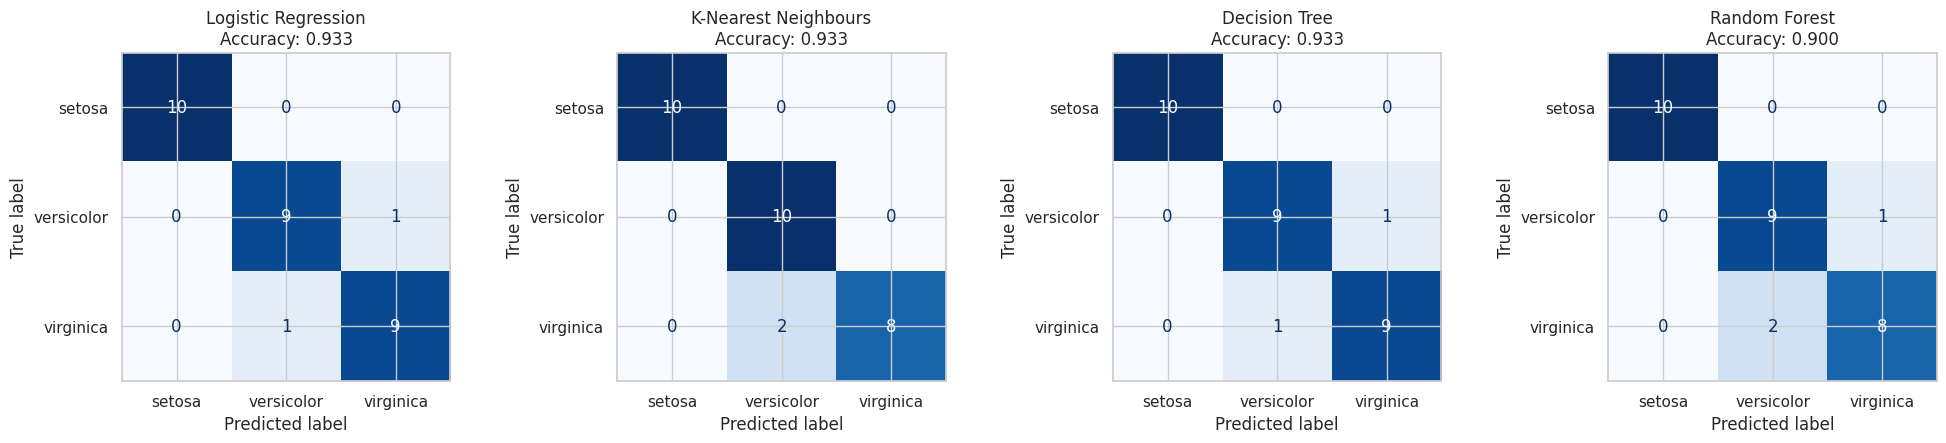

In [16]:
# Confusion matrices, side by side, for all four models
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

for ax, (name, model) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, results[name]["y_pred"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{name}\nAccuracy: {results[name]['accuracy']:.3f}")

fig.tight_layout()
plt.show()


In [17]:
# Side-by-side accuracy comparison
comparison = pd.DataFrame({
    "Model": list(results.keys()),
    "Accuracy": [results[name]["accuracy"] for name in results],
}).sort_values("Accuracy", ascending=False).reset_index(drop=True)

comparison


,Model,Accuracy
0,Logistic Regression,0.933333
1,K-Nearest Neighbours,0.933333
2,Decision Tree,0.933333
3,Random Forest,0.900000


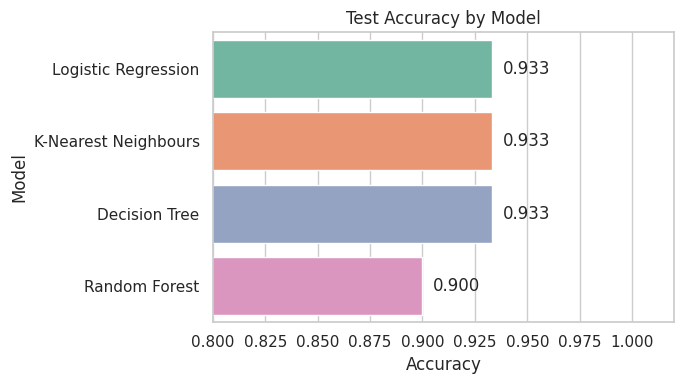

In [18]:
plt.figure(figsize=(7, 4))
sns.barplot(data=comparison, x="Accuracy", y="Model", hue="Model", palette="Set2", legend=False)
plt.xlim(0.8, 1.02)
plt.title("Test Accuracy by Model")
for i, acc in enumerate(comparison["Accuracy"]):
    plt.text(acc + 0.005, i, f"{acc:.3f}", va="center")
plt.tight_layout()
plt.show()


## 8. Best-Performing Model

The test set is only 30 rows, so a single split can easily let ties happen or let one
model "get lucky" on a couple of borderline *Versicolor*/*Virginica* flowers — a difference
of just one sample is already a 3.3% swing in accuracy. To make a more robust choice than a
single train/test split allows, we run **5-fold cross-validation on the full dataset** for
every model and compare the mean accuracy across folds.


In [19]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = []
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
    cv_results.append({
        "Model": name,
        "CV Mean Accuracy": scores.mean(),
        "CV Std": scores.std(),
    })

cv_comparison = pd.DataFrame(cv_results).sort_values("CV Mean Accuracy", ascending=False).reset_index(drop=True)
cv_comparison


,Model,CV Mean Accuracy,CV Std
0,K-Nearest Neighbours,0.973333,0.024944
1,Random Forest,0.960000,0.038873
2,Decision Tree,0.953333,0.033993
3,Logistic Regression,0.953333,0.045216


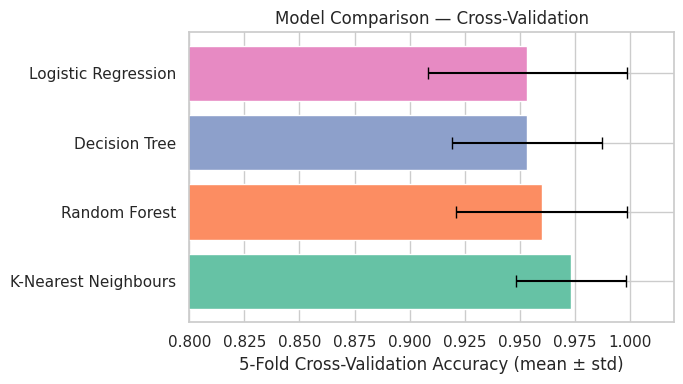

In [20]:
plt.figure(figsize=(7, 4))
plt.barh(cv_comparison["Model"], cv_comparison["CV Mean Accuracy"],
         xerr=cv_comparison["CV Std"], color=sns.color_palette("Set2"), capsize=4)
plt.xlim(0.8, 1.02)
plt.xlabel("5-Fold Cross-Validation Accuracy (mean ± std)")
plt.title("Model Comparison — Cross-Validation")
plt.tight_layout()
plt.show()


In [21]:
best_model_name = cv_comparison.iloc[0]["Model"]
best_cv_accuracy = cv_comparison.iloc[0]["CV Mean Accuracy"]
holdout_accuracy = comparison.set_index("Model").loc[best_model_name, "Accuracy"]

print(f"Best model (by 5-fold CV): {best_model_name}")
print(f"Cross-validation accuracy: {best_cv_accuracy:.4f}")
print(f"Single hold-out test accuracy: {holdout_accuracy:.4f}")


Best model (by 5-fold CV): K-Nearest Neighbours
Cross-validation accuracy: 0.9733
Single hold-out test accuracy: 0.9333


**Justification:**

On the single 80/20 hold-out split, **Logistic Regression, KNN, and the Decision Tree all
tied at 93.3%**, with Random Forest slightly behind at 90.0% — but with only 30 test rows,
that gap is a single misclassified flower and isn't a reliable signal on its own.

Averaging over **5-fold cross-validation** (every row gets used for testing exactly once,
across 5 different splits) gives a far more stable picture and resolves the tie:

- **K-Nearest Neighbours comes out on top** (~97.3% mean accuracy). The three species form
  tight, well-separated clusters in the 4-feature space — especially once petal length and
  petal width are involved — which is exactly the setting a distance-based method like KNN
  is built for: a new flower's nearest neighbours in feature space are almost always the
  correct species.
- **Random Forest** is a close second (~96.0%). Averaging many trees smooths out the
  occasional wrong split a single tree makes around the borderline
  *Versicolor*/*Virginica* boundary.
- **Decision Tree** and **Logistic Regression** tie for third (~95.3%). The single tree is
  still a little sensitive to exactly which points fall in each fold, while Logistic
  Regression — though very stable — is a linear model and gives up a small amount of
  accuracy on the slightly curved boundary between *Versicolor* and *Virginica*.

**Recommended model: K-Nearest Neighbours.** It achieves the highest mean accuracy under the
more trustworthy cross-validated estimate, and it also has the lowest variance across folds
(std ≈ 0.025) of all four models, meaning its performance is the most consistent regardless
of exactly how the data is split. Its only real cost is needing feature scaling and storing
the training data for inference — both trivial at this dataset's size — which is a small
price for the best and most reliable accuracy of the four models tested.


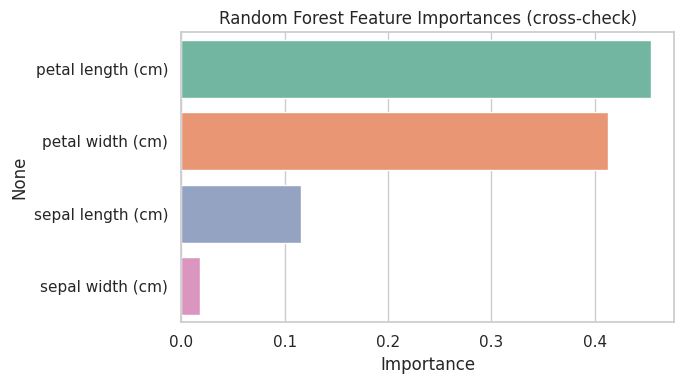

petal length (cm)    0.453793
petal width (cm)     0.412449
sepal length (cm)    0.115873
sepal width (cm)     0.017885
dtype: float64

In [22]:
# Feature importances from the Random Forest, purely as an independent cross-check —
# do the tree ensemble's importances agree with the ANOVA F-scores from Section 4?
rf_model = models["Random Forest"]
importances = pd.Series(rf_model.feature_importances_, index=iris.feature_names).sort_values(ascending=False)

plt.figure(figsize=(7, 4))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette="Set2", legend=False)
plt.title("Random Forest Feature Importances (cross-check)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances


This independently confirms the Section 4 conclusion: **petal length** and **petal width**
are by far the most important features for every model tried, while the sepal measurements
contribute only marginally.

## Summary

| Step | Outcome |
|---|---|
| Dataset | 150 samples, 4 features, 3 balanced classes, no missing values |
| Most discriminative features | Petal length & petal width (confirmed by EDA, ANOVA F-scores, and RF feature importances) |
| Models trained | Logistic Regression, KNN, Decision Tree, Random Forest |
| Model selection method | 80/20 hold-out split **and** 5-fold cross-validation (to resolve ties reliably) |
| Best model | **K-Nearest Neighbours** — top cross-validated accuracy (~97.3%) with the lowest variance across folds |

This notebook demonstrates a complete, reproducible classification workflow: load → explore →
visualise → select features → split → train multiple models → evaluate → justify the final
model choice using a robust, cross-validated comparison.
